# Import Libraries

In [3]:
import numpy as np
import pandas as pd 

### Data loading

In [4]:
# For SKUs starting with '90'
# Data loading
df = pd.read_csv('../data/ForecastDataset_from_2016_To_2024_for_all_SKUs.csv')

In [5]:
df.shape

(1048575, 10)

In [6]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip
0,AIRD,54522457,12/23/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403
1,AIRD,54526264,12/28/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326
2,AIRD,54536438,12/30/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806
3,AIRD,54536647,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,94903
4,AIRD,54537034,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,48310


In [7]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_category', 'Channel', 'ShipToState',
       'ShippingZip'],
      dtype='object')

### Missing (null) values

In [8]:
df.isna().sum()

ProductFamily            0
Order_ID                 0
OrderDate                0
SKU_Description      54667
WareHouseQuantity     4955
SKU                  10630
SKU_category         59623
Channel              12431
ShipToState            240
ShippingZip              3
dtype: int64

### Feature Engineering

In [9]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

### Data Overview & Quality Checks
- `Basic Stats and Structure`

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   ProductFamily      1048575 non-null  object        
 1   Order_ID           1048575 non-null  int64         
 2   OrderDate          1048575 non-null  datetime64[ns]
 3   SKU_Description    993908 non-null   object        
 4   WareHouseQuantity  1043620 non-null  float64       
 5   SKU                1037945 non-null  object        
 6   SKU_category       988952 non-null   object        
 7   Channel            1036144 non-null  object        
 8   ShipToState        1048335 non-null  object        
 9   ShippingZip        1048572 non-null  object        
 10  Week               1048575 non-null  datetime64[ns]
 11  Month              1048575 non-null  int32         
 12  Year               1048575 non-null  int32         
dtypes: datetime64[ns](2), float

In [11]:
df.describe()

,Order_ID,OrderDate,WareHouseQuantity,Week,Month,Year
count,1.048575e+06,1048575,1.043620e+06,1048575,1.048575e+06,1.048575e+06
mean,4.118648e+07,2022-04-15 03:53:42.907659776,1.176947e+00,2022-04-12 08:02:34.248194560,7.128582e+00,2.021734e+03
min,1.554000e+03,2016-12-23 00:00:00,1.000000e+00,2016-12-19 00:00:00,1.000000e+00,2.016000e+03
25%,2.207445e+05,2021-05-20 00:00:00,1.000000e+00,2021-05-17 00:00:00,4.000000e+00,2.021000e+03
50%,6.004868e+07,2022-06-24 00:00:00,1.000000e+00,2022-06-20 00:00:00,8.000000e+00,2.022000e+03
75%,6.147562e+07,2023-06-11 00:00:00,1.000000e+00,2023-06-05 00:00:00,1.100000e+01,2.023000e+03
max,6.246150e+07,2024-04-29 00:00:00,3.000000e+01,2024-04-29 00:00:00,1.200000e+01,2.024000e+03
std,2.831120e+07,NaN,5.052335e-01,NaN,3.595435e+00,1.443826e+00


In [12]:
df.nunique()

ProductFamily             1
Order_ID             763423
OrderDate              2648
SKU_Description          86
WareHouseQuantity        24
SKU                      93
SKU_category              9
Channel                  33
ShipToState              98
ShippingZip           50110
Week                    385
Month                    12
Year                      9
dtype: int64

- `Missing Values`

In [13]:
missing = df.isnull().sum()
print(missing[missing > 0])


SKU_Description      54667
WareHouseQuantity     4955
SKU                  10630
SKU_category         59623
Channel              12431
ShipToState            240
ShippingZip              3
dtype: int64


- `SKU Distribution`

In [14]:
# Total SKUs
total_skus = df['SKU'].nunique()

# SKU distribution per state
sku_per_state = df.groupby('ShipToState')['SKU'].nunique().sort_values(ascending=False)


In [15]:
total_skus

93

In [16]:
sku_per_state

ShipToState
TX            86
CA            84
NY            83
FL            83
NJ            82
              ..
Rincón         1
Washington     1
co             1
guam           1
nv             1
Name: SKU, Length: 98, dtype: int64

- `Outlier Detection (WareHouseQuantity)`
1) Most values of WareHouseQuantity are tightly clustered around 1 to 2 units, as seen by the tall vertical box line.

2) Outliers are clearly visible, going up to 30 units. These could be bulk orders or data anomalies.

Text(0.5, 1.0, 'Outlier Detection for WareHouseQuantity')

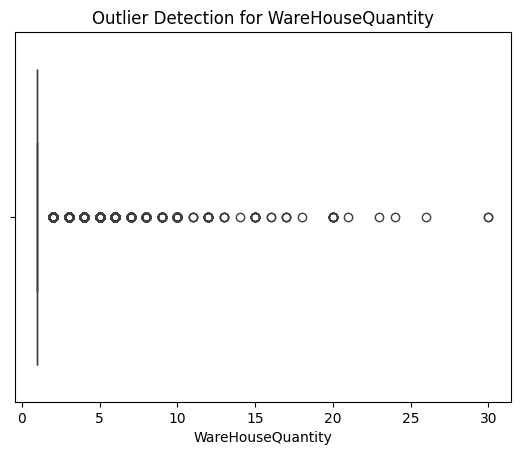

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['WareHouseQuantity'])
plt.title("Outlier Detection for WareHouseQuantity")


### Temporal Patterns and Trends
- `Overall Trend (weekly and monthly)`

<Axes: title={'center': 'Monthly SKU Category Trend'}, xlabel='Month'>

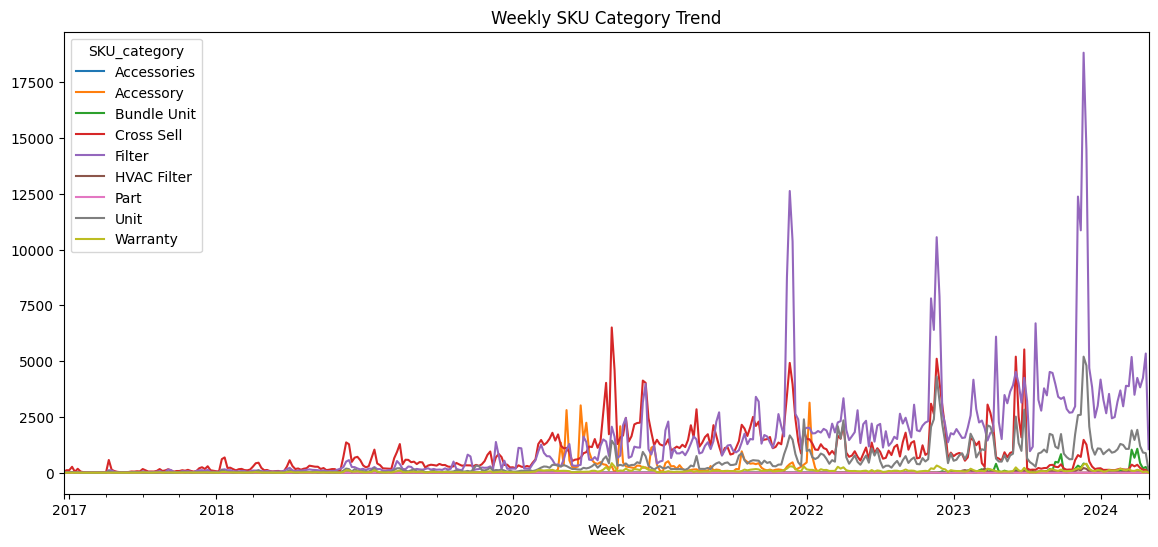

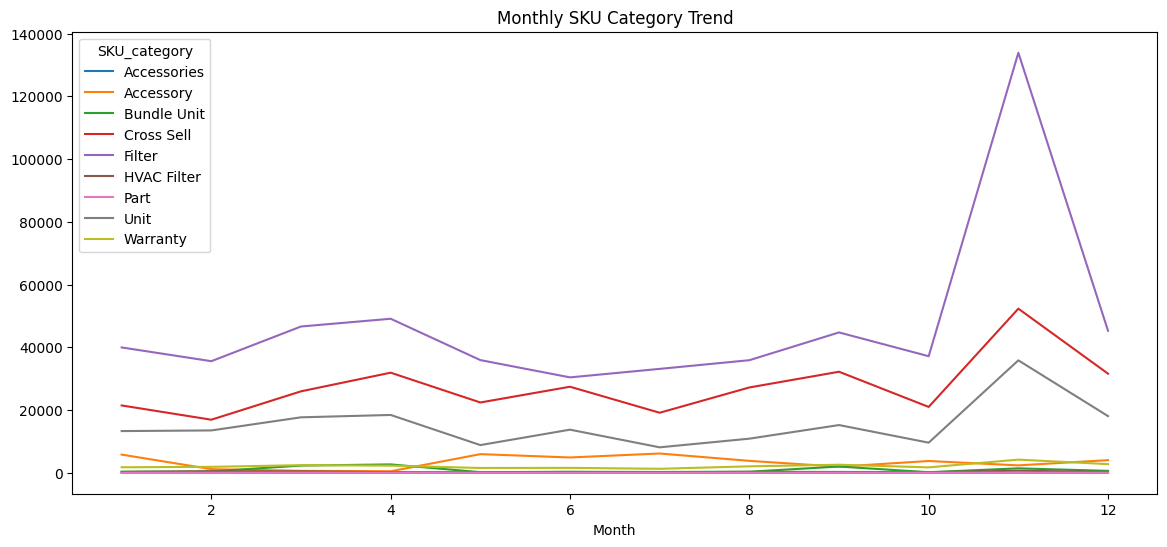

In [18]:
weekly_trend = df.groupby(['Week', 'SKU_category'])['WareHouseQuantity'].sum().unstack().fillna(0)
monthly_trend = df.groupby(['Month', 'SKU_category'])['WareHouseQuantity'].sum().unstack().fillna(0)

weekly_trend.plot(figsize=(14, 6), title='Weekly SKU Category Trend')
monthly_trend.plot(figsize=(14, 6), title='Monthly SKU Category Trend')


- `Seasonal Trends (peaks/dips)`

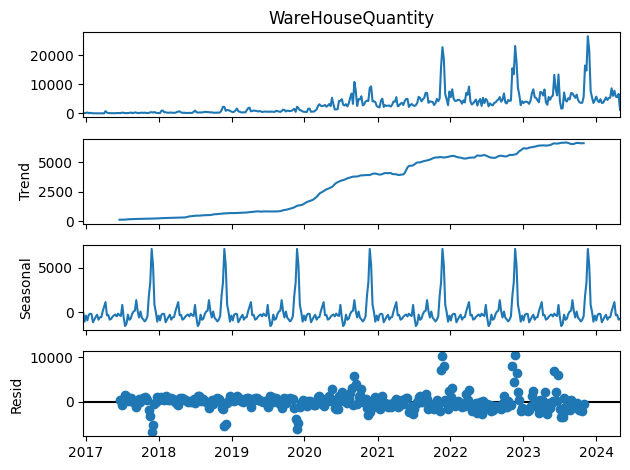

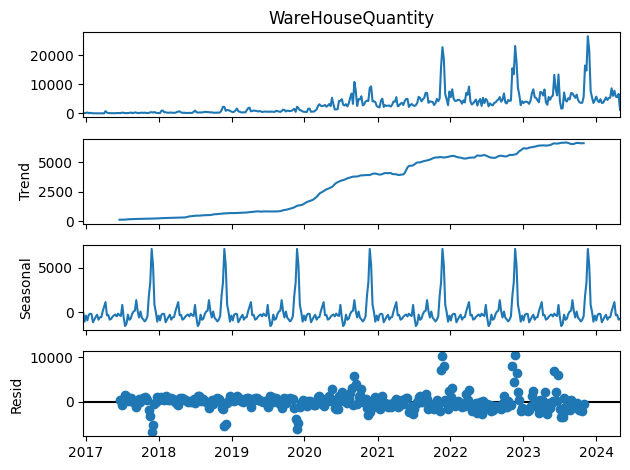

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = df.groupby('Week')['WareHouseQuantity'].sum()
result = seasonal_decompose(series, model='additive')
result.plot()


- ` State-wise Trend`

In [20]:
import plotly.graph_objects as go
import pandas as pd

# Step 1: Compute total quantity per state and get top 10 states
top_states = df.groupby('ShipToState')['WareHouseQuantity'].sum().nlargest(10).index

# Step 2: Create the pivot table for weekly trend
state_trend = df.groupby(['Week', 'ShipToState'])['WareHouseQuantity'].sum().unstack().fillna(0)

# Step 3: Filter columns to include only top 10 states
state_trend_top10 = state_trend[top_states]

# Step 4: Create Plotly line chart
fig = go.Figure()

# Add one line per state
for state in state_trend_top10.columns:
    fig.add_trace(go.Scatter(
        x=state_trend_top10.index,
        y=state_trend_top10[state],
        mode='lines+markers',
        name=state
    ))

# Customize layout
fig.update_layout(
    title='Weekly Warehouse Quantity Trend - Top 10 States',
    xaxis_title='Year',
    yaxis_title='Warehouse Quantity',
    legend_title='State',
    width=1000,
    height=600,
    hovermode='x unified'
)

fig.show()


In [21]:
import plotly.graph_objects as go
import pandas as pd

# Step 1: Compute total quantity per state and get top 10 states
top_states = df.groupby('ShipToState')['WareHouseQuantity'].sum().nlargest(10).index

# Step 2: Create the pivot table for weekly trend
state_trend = df.groupby(['Week', 'ShipToState'])['WareHouseQuantity'].sum().unstack().fillna(0)

# Step 3: Filter columns to include only top 10 states
state_trend_top10 = state_trend[top_states]

# Step 4: Create Plotly line chart with formatted hover and x-axis
fig = go.Figure()

# Custom color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Add one smooth line per state
for i, state in enumerate(state_trend_top10.columns):
    fig.add_trace(go.Scatter(
        x=state_trend_top10.index,
        y=state_trend_top10[state],
        mode='lines',
        name=state,
        line=dict(shape='spline', color=colors[i % len(colors)], width=2.5),
        fill='tozeroy',
        hovertemplate=f"<b>{state}</b><br>Week Start: %{{x|%Y-%m-%d}}<br>Quantity: %{{y:,}}<extra></extra>"
    ))

# Format x-axis to show full dates
fig.update_xaxes(
    title='Week',
    tickformat="%Y-%m-%d",       # e.g., "2024-07-01"
    tickangle=45,
    showgrid=True
)

# Customize layout
fig.update_layout(
    title='<b>Weekly Warehouse Quantity Trend — Top 10 States</b>',
    title_font_size=22,
    xaxis_title='Week Start Date',
    yaxis_title='Warehouse Quantity',
    legend_title='State',
    template='plotly_white',
    font=dict(family='Segoe UI, sans-serif', size=14),
    width=1100,
    height=600,
    hovermode='x unified',
    plot_bgcolor='rgba(245, 247, 251, 1)',
    paper_bgcolor='rgba(240, 240, 240, 1)',
    margin=dict(t=60, l=60, r=30, b=90)  # more bottom space for angled ticks
)

fig.show()


### Geographical Patterns
- **`State-wise Distribution of Total Warehouse Inventory`**

C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_11124\3091767652.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




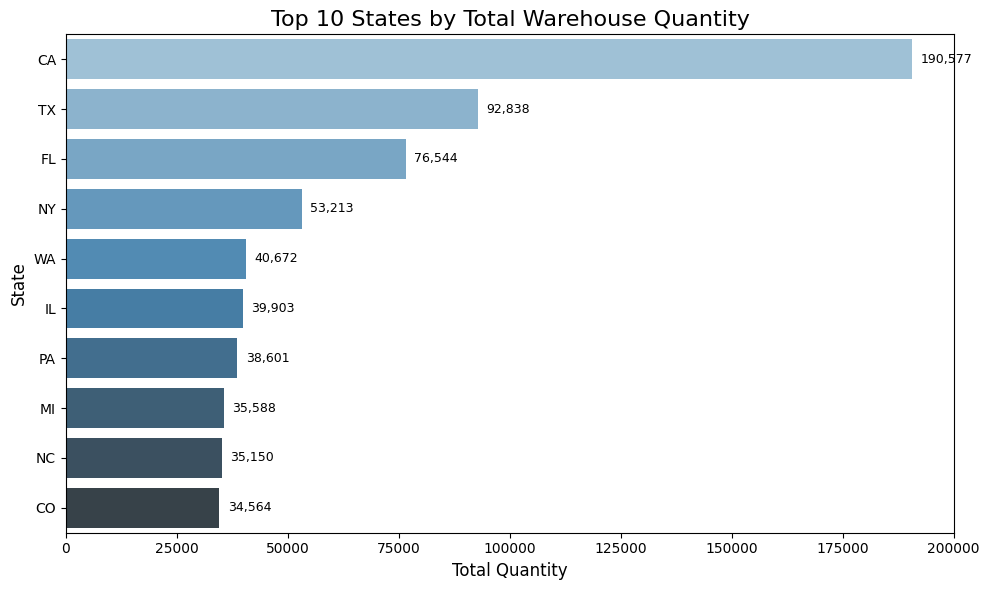

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group, sort, and select top 10 states
state_quantity = df.groupby('ShipToState')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)

# Set figure size
plt.figure(figsize=(10, 6))

# Create the barplot
ax = sns.barplot(x=state_quantity.values, y=state_quantity.index, palette='Blues_d')

# Title and axis labels
plt.title("Top 10 States by Total Warehouse Quantity", fontsize=16)
plt.xlabel("Total Quantity", fontsize=12)
plt.ylabel("State", fontsize=12)

# Add text labels on bars
offset = state_quantity.max() * 0.01  # use .max() as a method
for i, (value, state) in enumerate(zip(state_quantity.values, state_quantity.index)):
    ax.text(value + offset, i, f'{int(value):,}', va='center', fontsize=9)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()


- **`U.S. State-Level Warehouse Demand Heatmap`**
1) **Choropleth Map:** A thematic map where areas are shaded in proportion to the value of a variable (in this case, WareHouseQuantity).

2) **Heatmap (in this context):** Refers to the varying intensity of color to represent demand.

In [23]:
import plotly.express as px

state_qty = df.groupby('ShipToState')['WareHouseQuantity'].sum().reset_index()
fig = px.choropleth(state_qty,
                    locations='ShipToState',
                    locationmode="USA-states",
                    color='WareHouseQuantity',
                    scope="usa",
                    title='Warehouse Demand Distribution Heatmap Across U.S. States')
fig.show()


###  SKU/Product-Level Analysis
- **`Top SKUs`**

<Axes: title={'center': 'Top 10 SKUs by Demand'}, ylabel='SKU_Description'>

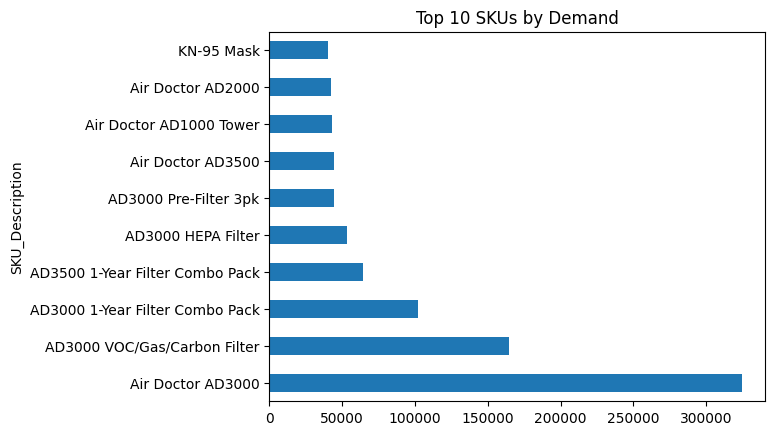

In [24]:
top_skus = df.groupby('SKU_Description')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)
top_skus.plot(kind='barh', title="Top 10 SKUs by Demand")


### Correlation and Dependency Analysis

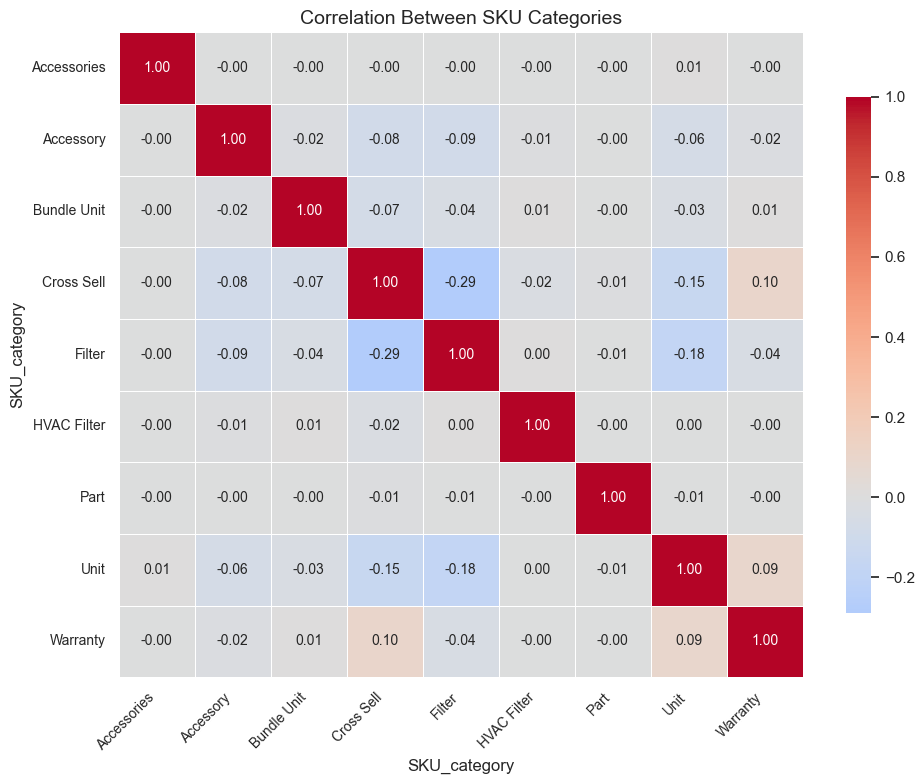

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# STEP 1: Pivot to get a matrix where each row is an order and columns are SKU categories
sku_corr = df.pivot_table(
    index='Order_ID',
    columns='SKU_category',
    values='WareHouseQuantity',
    aggfunc='sum'
).fillna(0)

# STEP 2: Compute the correlation matrix
corr_matrix = sku_corr.corr()

# STEP 3: Plotting the heatmap
plt.figure(figsize=(10, 8))  # Set figure size for better readability
sns.set(style="whitegrid")

ax = sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Two decimal places
    cmap="coolwarm",    # Color palette
    center=0,           # Center colormap at 0
    linewidths=0.5,     # Line between cells
    cbar_kws={"shrink": 0.8},  # Shrink colorbar
    annot_kws={"size": 10}     # Annotation text size
)

plt.title("Correlation Between SKU Categories", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


### Weekly Sales Trend

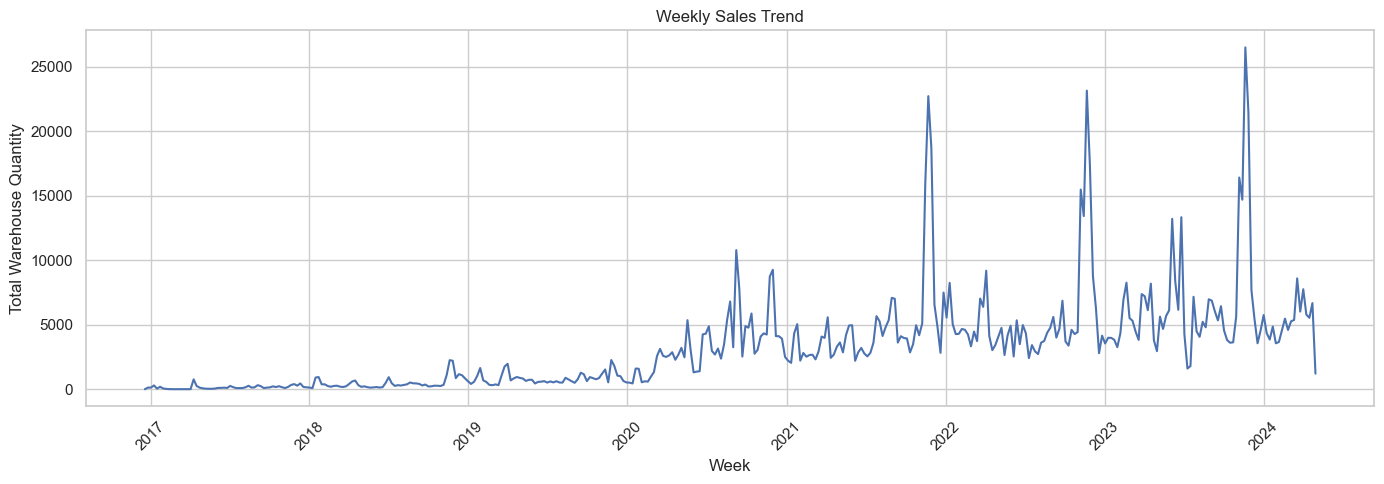

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

weekly_trend = df.groupby('Week')['WareHouseQuantity'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuantity')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Warehouse Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top 10 SKUs

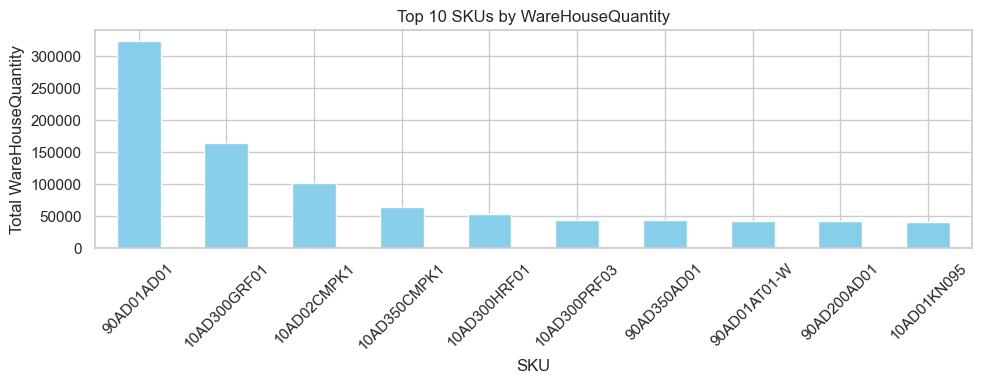

In [27]:
top_skus = df.groupby('SKU')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_skus.plot(kind='bar', color='skyblue')
plt.title("Top 10 SKUs by WareHouseQuantity")
plt.ylabel("Total WareHouseQuantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Range Of SKUs

In [28]:
def print_date_ranges(df, sku_list=None):
    """
    Prints the overall dataset date range and individual date ranges for specified SKUs.

    Parameters:
    df (pd.DataFrame): DataFrame containing at least 'OrderDate' and 'SKU' columns.
    sku_list (list, optional): List of SKU strings to check date ranges for.
    """
    print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())
    
    if sku_list:
        for sku in sku_list:
            df_sku_check = df[df['SKU'] == sku]
            if not df_sku_check.empty:
                print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())
                # print(f"Total weekly data points for this SKU: {df_sku_check.shape[0]}")
            else:
                print(f"No data found for SKU: {sku}")
                


In [29]:
sku_list = ['90AD350AD01', '90AD200AD01', '90AD01AT01-W', '90AD02AD01', '90AD550AD01']
print_date_ranges(df, sku_list)


Full dataset date range: 2016-12-23 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD350AD01: 2022-09-15 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD200AD01: 2022-06-04 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD01AT01-W: 2019-08-16 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD02AD01: 2021-05-25 00:00:00 to 2023-06-30 00:00:00
Selected SKU date range 90AD550AD01: 2022-09-15 00:00:00 to 2024-04-29 00:00:00


### Active, Inactive SKU's

**`1. Convert OrderDate to datetime and Group By SKU and OrderDate`**

In [30]:
# Convert 'OrderDate' to datetime format
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
latest_date = df['OrderDate'].max()

# Group by SKU and get the last order date
sku_last_date = df.groupby('SKU')['OrderDate'].max().reset_index()
sku_last_date['Status'] = sku_last_date['OrderDate'].apply(lambda x: 'Active' if x == latest_date else 'Inactive')



In [31]:
# Group by SKU and get the last order date
sku_status_counts = sku_last_date['Status'].value_counts().reset_index()
sku_status_counts.columns = ['Status', 'Count']
print(sku_status_counts)


     Status  Count
0  Inactive     58
1    Active     35


**`Visualization: Active vs Inactive`**

C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_11124\3057051633.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




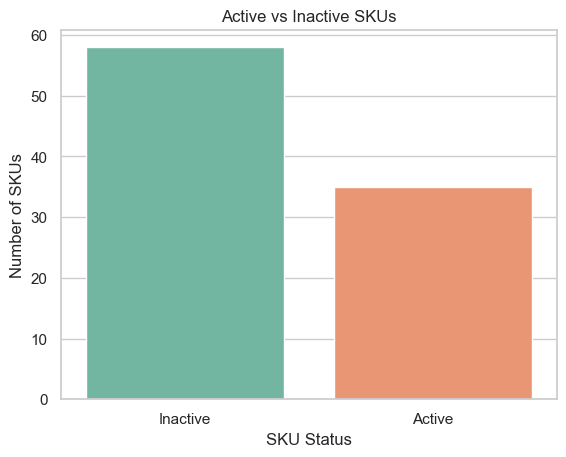

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.barplot(data=sku_status_counts, x='Status', y='Count', palette='Set2')
plt.title("Active vs Inactive SKUs")
plt.ylabel("Number of SKUs")
plt.xlabel("SKU Status")
plt.show()


In [33]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
latest_date = df['OrderDate'].max()
sku_ranges = df.groupby('SKU')['OrderDate'].agg(['min', 'max']).reset_index()
sku_ranges.columns = ['SKU', 'StartDate', 'EndDate']
sku_ranges['Status'] = sku_ranges['EndDate'].apply(lambda x: 'Active' if x == latest_date else 'Inactive')


### SKU Activity Timeline (All Active & Inactive SKUs)

In [34]:
import pandas as pd
import plotly.express as px

#  Ensure 'OrderDate' is in datetime format
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

#  Get the latest order date in dataset
latest_date = df['OrderDate'].max()

#  Group by SKU to get first and last order dates
sku_ranges = df.groupby('SKU')['OrderDate'].agg(['min', 'max']).reset_index()
sku_ranges.columns = ['SKU', 'StartDate', 'EndDate']

#  Label each SKU as 'Active' or 'Inactive'
sku_ranges['Status'] = sku_ranges['EndDate'].apply(lambda x: 'Active' if x == latest_date else 'Inactive')

#  Create interactive Gantt-style timeline chart
fig = px.timeline(
    sku_ranges,
    x_start="StartDate",
    x_end="EndDate",
    y="SKU",
    color="Status",
    color_discrete_map={'Active': 'green', 'Inactive': 'red'},
    title="SKU Activity Timeline (All Active & Inactive SKUs)"
)

#  Format the chart
fig.update_yaxes(autorange="reversed")  # Show top SKU at top
fig.update_layout(
    xaxis_title="Date Range",
    yaxis_title="SKU",
    legend_title="SKU Status",
    height=800,
    margin=dict(l=50, r=50, t=80, b=50)
)

#  Show chart
fig.show()


#### Top 10 Active SKU's Timeline(Gantt Chart)

In [35]:
import pandas as pd
import plotly.express as px


# Ensure datetime conversion
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Get latest order date in dataset
latest_date = df['OrderDate'].max()

# Group by SKU to get first and last appearance
sku_ranges = df.groupby('SKU')['OrderDate'].agg(['min', 'max']).reset_index()
sku_ranges.columns = ['SKU', 'StartDate', 'EndDate']

# Add Active/Inactive status
sku_ranges['Status'] = sku_ranges['EndDate'].apply(lambda x: 'Active' if x == latest_date else 'Inactive')

# OPTIONAL: Filter top 10 active SKUs
top_active = sku_ranges[sku_ranges['Status'] == 'Active'].sort_values('StartDate').head(10)

# Plotly Timeline
fig = px.timeline(
    top_active,
    x_start="StartDate",
    x_end="EndDate",
    y="SKU",
    color="Status",
    color_discrete_map={'Active': 'green', 'Inactive': 'red'},
    title="Top 10 Active SKUs Timeline"
)

fig.update_yaxes(autorange="reversed")  # To display top SKU at top
fig.update_layout(
    xaxis_title="Date Range",
    yaxis_title="SKU",
    legend_title="Status",
    height=600
)

fig.show()


### SKU Activity Timeline (Active vs Inactive)

In [36]:
import plotly.express as px
import pandas as pd

# Ensure datetime format
sku_ranges['StartDate'] = pd.to_datetime(sku_ranges['StartDate'])
sku_ranges['EndDate'] = pd.to_datetime(sku_ranges['EndDate'])

# Define color mapping
color_map = {'Active': 'green', 'Inactive': 'red'}

# Create timeline chart
fig = px.timeline(
    sku_ranges,
    x_start="StartDate",
    x_end="EndDate",
    y="SKU",
    color="Status",
    color_discrete_map=color_map,
    title="SKU Activity Timeline (Active vs Inactive)"
)

# Reverse Y-axis to match barh
fig.update_yaxes(autorange="reversed")

# Add grid and formatting
fig.update_layout(
    xaxis_title="Date Range",
    yaxis_title="SKU",
    legend_title="SKU Status",
    xaxis=dict(
        showgrid=True,
        gridcolor='LightGray',
        tickformat='%Y',  # Format x-axis as years
        dtick="M12"       # Tick every 12 months
    ),
    height=600,
    margin=dict(l=120, r=20, t=60, b=40)
)

fig.show()


#### SKU Activity Timeline (Active vs Inactive) For all SKUs

In [37]:
import plotly.express as px

# Define color mapping
color_map = {'Active': 'green', 'Inactive': 'red'}

# Plot all SKUs with Plotly
fig = px.timeline(
    sku_ranges,
    x_start="StartDate",
    x_end="EndDate",
    y="SKU",
    color="Status",
    color_discrete_map=color_map,
    title="SKU Activity Timeline (Active vs Inactive)"
)

# Reverse Y-axis to match typical Gantt chart style
fig.update_yaxes(autorange="reversed")

# Customize layout
fig.update_layout(
    xaxis_title="Date Range",
    yaxis_title="SKU",
    legend_title="SKU Status",
    xaxis=dict(
        showgrid=True,
        gridcolor='LightGray',
        tickformat='%Y',
        dtick="M12"  # Year ticks
    ),
    height=max(600, 20 * len(sku_ranges)),  # Adjust height based on number of SKUs
    margin=dict(l=120, r=20, t=60, b=40)
)

fig.show()
